In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
plt.style.use('ggplot')

In [2]:
X, y = make_moons(n_samples=200, noise=0.1, random_state=0)

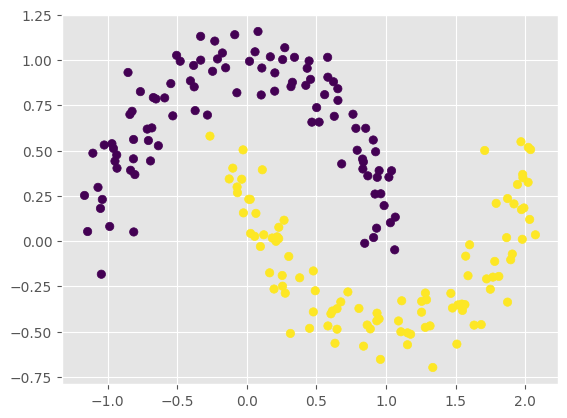

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)

In [4]:
def plot_decision_boundary(model, xlim=(-1.5, 2.5), ylim=(-1, 1.5), grid_size=100):
    x1 = np.linspace(*xlim, grid_size)
    x2 = np.linspace(*ylim, grid_size)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    logits = model.forward(grid, training=False).reshape(xx1.shape)
    plt.contourf(xx1, xx2, logits > 0, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    return logits

In [5]:
# ── activations ────────────────────────────────────────────────────
def relu(z):       return np.maximum(0, z)
def relu_grad(z):  return (z > 0).astype(float)
def sigmoid(z):    return 1 / (1 + np.exp(-np.clip(z, -100, 100)))

# ── He initialisation ──────────────────────────────────────────────
def he_init(fan_in, fan_out, rng=np.random.default_rng()):
    return rng.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out))

## Layer backward passes — derivatives

Each layer implements `backward(dout)` where `dout` $= \frac{\partial L}{\partial z}$ is the gradient flowing in from the layer above. Each layer must return $\frac{\partial L}{\partial x}$ to pass back further, and accumulate any parameter gradients ($dW$, $db$, etc.).

$$\frac{\partial L}{\partial x} = \frac{\partial z}{\partial x} \frac{\partial L}{\partial z} = \frac{\partial z}{\partial x} \cdot d_{out}$$

<br>

$$\frac{\partial L}{\partial W} = \frac{\partial z}{\partial W} \frac{\partial L}{\partial z}= \frac{\partial z}{\partial W} \cdot d_{out}$$
**B: Batch size**

---

### ReLU

**Forward:** $z = \max(0,\, x)$

ReLU is piecewise linear, so its derivative is just an indicator:

$$\frac{\partial z}{\partial x} = \mathbf{1}[x > 0]$$

**Backward:**

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \cdot \mathbf{1}[x > 0]$$

Units where $x \le 0$ during the forward pass pass back **zero gradient** — they're "dead" for that step. That's why the input $x$ must be cached: we need to know which gates were open.

---

### Linear

**Forward:** $Z = X W + b \quad$ shapes: $(B,\, d_\text{in}) \times (d_\text{in},\, d_\text{out}) \to (B,\, d_\text{out})$

Think of $L$ as a function of $Z$. Three things to differentiate:

$$\frac{\partial L}{\partial W} = \frac{1}{B}\, X^T \frac{\partial L}{\partial Z} \qquad (d_\text{in},\, d_\text{out})$$

$$\frac{\partial L}{\partial b} = \frac{1}{B} \sum_{i=1}^{B} \frac{\partial L}{\partial Z_i} \qquad (d_\text{out},)$$

$$\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Z}\, W^T \qquad (B,\, d_\text{in}) \quad \leftarrow \text{passed back}$$

The $\frac{1}{B}$ on $dW$ and $db$ averages over the batch — consistent with computing the loss as a mean rather than a sum.  
The input $x$ must be cached because $\frac{\partial L}{\partial W}$ depends on it.

---

### Dropout (inverted)

**Forward (training):** Each unit is zeroed with probability $p$. Surviving units are immediately rescaled by $\frac{1}{1-p}$ (inverted dropout) so their expected value is unchanged — no correction needed at test time.

$$z_i = \frac{x_i \cdot m_i}{1-p}, \qquad m_i \sim \text{Bernoulli}(1-p)$$

**Backward:** Reuse the same mask:

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \cdot m$$

The $\frac{1}{1-p}$ rescaling is already baked into $m$, so zeroed units get zero gradient and active units get their gradient scaled up by the same factor as the activation. At inference $p=0$, the layer is a no-op in both directions.

---

### BatchNorm

**Forward:**

$$\hat{x} = \frac{x - \mu_B}{\sigma_B}, \qquad y = \gamma\,\hat{x} + \beta$$

where $\mu_B = \frac{1}{B}\sum x_i$ and $\sigma_B = \sqrt{\text{Var}(x) + \varepsilon} $.
and $\text{Var}(x) = \frac{1}{B} \sum (x_i - \mu_B)^2$

**Backward** (Ioffe & Szegedy, 2015):

The parameters $\gamma$ and $\beta$ accumulate gradients directly:

$$\frac{\partial L}{\partial \gamma} = \sum_i \frac{\partial L}{\partial y_i} \cdot \hat{x}_i \qquad \frac{\partial L}{\partial \beta} = \sum_i \frac{\partial L}{\partial y_i}$$

The tricky part is $\frac{\partial L}{\partial x}$. Because $\mu_B$ and $\sigma_B$ are themselves computed from $x$, the gradient has **three paths** back through the graph:

$$\frac{\partial L}{\partial \hat{x}} = \frac{\partial L}{\partial y} \cdot \gamma$$

$$\frac{\partial L}{\partial \sigma_B^2} = \sum_i \frac{\partial L}{\partial \hat{x}_i} \cdot (x_i - \mu_B) \cdot \left(-\tfrac{1}{2}\right) \sigma_B^{-3}$$

$$\frac{\partial L}{\partial \mu_B} = \sum_i \frac{-\partial L / \partial \hat{x}_i}{\sigma_B} + \frac{\partial L}{\partial \sigma_B^2} \cdot \frac{-2}{B}\sum_i(x_i - \mu_B)$$

$$\boxed{\frac{\partial L}{\partial x_i} = \frac{\partial L / \partial \hat{x}_i}{\sigma_B} + \frac{\partial L}{\partial \sigma_B^2} \cdot \frac{2(x_i - \mu_B)}{B} + \frac{\partial L}{\partial \mu_B} \cdot \frac{1}{B}}$$

Each term corresponds to one line in `backward()`. Caching $\hat{x}$, $\sigma_B$, and $(x - \mu_B)$ during the forward pass avoids recomputing them.

---

---

## Linear backward — full derivation

### Setup

Forward pass: $Z = XW + b$

| Symbol | Shape | Meaning |
|---|---|---|
| $X$ | $(B,\; d_\text{in})$ | batch of inputs |
| $W$ | $(d_\text{in},\; d_\text{out})$ | weight matrix |
| $b$ | $(d_\text{out},)$ | bias vector |
| $Z$ | $(B,\; d_\text{out})$ | output, passed to next layer |

$\frac{\partial L}{\partial Z}$ arrives from the layer above, same shape as $Z$: $(B,\; d_\text{out})$.  
We need to compute $\frac{\partial L}{\partial W}$, $\frac{\partial L}{\partial b}$, and $\frac{\partial L}{\partial X}$.

---

### Step 0 — think element-wise first

Matrices are intimidating. The trick: write one scalar element of $Z$, differentiate that, then recognise the matrix pattern at the end.

$$z_{ij} = \sum_{k=1}^{d_\text{in}} x_{ik}\, w_{kj} + b_j$$

where $i$ indexes the sample in the batch, $j$ indexes the output dimension, $k$ indexes the inner dimension.

---

### Why transpose for $dW$ ?

Pick one weight $w_{pq}$. How does it affect the loss?

It appears in every $z_{iq}$ for all samples $i$:

$$\frac{\partial z_{ij}}{\partial w_{pq}} = x_{ip} \cdot \mathbf{1}[j = q]$$

By the chain rule, summing over all $(i, j)$:

$$\frac{\partial L}{\partial w_{pq}} = \sum_{i,j} \frac{\partial L}{\partial z_{ij}} \cdot \frac{\partial z_{ij}}{\partial w_{pq}} = \sum_i \frac{\partial L}{\partial z_{iq}} \cdot x_{ip}$$

That's: for a fixed output column $q$, sum over all samples the product of the incoming gradient and the input. In matrix form, that's exactly the $(p, q)$ entry of $X^T \cdot \frac{\partial L}{\partial Z}$:

$$\frac{\partial L}{\partial W} = X^T\; \frac{\partial L}{\partial Z} \qquad (d_\text{in},\; d_\text{out})$$

**The transpose appears because** $W$ connects input dimension $p$ to output dimension $q$, but in $Z = XW$ the input dimension is the *row* of $X$ and the *column* of $W$ — so to align the summation over samples $i$, you need to flip $X$.

---

### Why sum for $db$ ?

Pick one bias $b_q$. It shifts **every** $z_{iq}$ for all samples $i$:

$$\frac{\partial z_{ij}}{\partial b_q} = \mathbf{1}[j = q]$$

$$\frac{\partial L}{\partial b_q} = \sum_{i,j} \frac{\partial L}{\partial z_{ij}} \cdot \frac{\partial z_{ij}}{\partial b_q} = \sum_i \frac{\partial L}{\partial z_{iq}}$$

The bias is a single vector shared by all $B$ samples — so its gradient accumulates a contribution from every sample in the batch. That's a **sum over axis 0** (the batch axis):

$$\frac{\partial L}{\partial b} = \sum_i \frac{\partial L}{\partial Z_i} \qquad (d_\text{out},)$$

There's no matrix multiply here — $b$ has no "input dimension" to contract against.

---

### Why $\frac{1}{B}$ only on $dW$ and $db$, not $dX$ ?

$W$ and $b$ are **shared** across all $B$ samples. Their gradient is the mean of per-sample contributions — consistent with computing the loss as a mean rather than a sum:

$$\frac{\partial L}{\partial W} = \frac{1}{B} X^T \frac{\partial L}{\partial Z} \qquad \frac{\partial L}{\partial b} = \frac{1}{B}\sum_i \frac{\partial L}{\partial Z_i}$$

$X$ has **one row per sample** — each row gets its own independent gradient. There's nothing to average: row $i$ of $\frac{\partial L}{\partial X}$ is the gradient for sample $i$ only. Dividing by $B$ would incorrectly shrink the signal passed back to earlier layers.

---

### Summary

| Gradient | Formula | Why |
|---|---|---|
| $\frac{\partial L}{\partial W}$ | $\frac{1}{B} X^T \frac{\partial L}{\partial Z}$ | contract over batch ($i$), transpose to align dims |
| $\frac{\partial L}{\partial b}$ | $\frac{1}{B}\sum_i \frac{\partial L}{\partial Z_i}$ | $b$ is shared — sum over batch, no inner dim to contract |
| $\frac{\partial L}{\partial X}$ | $\frac{\partial L}{\partial Z}\, W^T$ | contract over output dim ($j$), transpose to align dims |

In [6]:
# ── base layer ───────────────────────────────────────────────────
class Layer:
    def forward(self, x):
        pass
    def backward(self, dout):
        pass
    def get_params(self):
        return []
    
# ── relu layer ───────────────────────────────────────────────────
class ReLU(Layer):
    def __init__(self):
        self._x = None # cache for backprop

    def forward(self, x):
        self._x = x # not needed for forward, here no "no_grad" mode for inference
        return relu(x)

    def backward(self, dout):
        return dout * relu_grad(self._x)

# ── linear layer ───────────────────────────────────────────────────
class Linear(Layer):
    def __init__(self, in_dim, out_dim, rng):
        self.W  = he_init(in_dim, out_dim, rng)   # (in, out)
        self.b  = np.zeros(out_dim)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._x = None                             # cache for backprop

    def forward(self, x):
        self._x = x                                # cache input
        return x @ self.W + self.b                 # (B, out)

    def backward(self, dout):
        # dout: (B, out) — gradient from upstream
        self.dW = self._x.T @ dout / len(dout)    # (in, out)
        self.db = dout.mean(axis=0)               # (out,)
        return dout @ self.W.T                    # (B, in) → pass back

    def get_params(self):
        return [(self.W, self.dW), (self.b, self.db)]

# ── dropout ────────────────────────────────────────────────────────
class Dropout(Layer):
    def __init__(self, p=0.3):
        self.p = p
        self._mask = None

    def forward(self, x, training=True):
        if not training or self.p == 0:
            return x
        self._mask = (np.random.rand(*x.shape) > self.p) / (1 - self.p)
        return x * self._mask # inverted dropout

    def backward(self, dout):
        return dout * self._mask

# ── batch normalisation ────────────────────────────────────────────
class BatchNorm(Layer):
    def __init__(self, dim, eps=1e-8, momentum=0.9):
        self.gamma = np.ones(dim)                  # learned scale
        self.beta = np.zeros(dim)                 # learned shift
        self.dgamma = np.zeros_like(self.gamma)    # gradient for gamma
        self.dbeta = np.zeros_like(self.beta)     # gradient for beta
        
        self.eps = eps
        self.mom = momentum
        self.running_mean = np.zeros(dim)          # for inference
        self.running_var  = np.ones(dim)
        # cache for backprop
        self._xhat = None
        self._std = None
        self._x_mu = None

    def forward(self, x, training=True):
        if training:
            mu  = x.mean(axis=0)
            var = x.var(axis=0)
            self.running_mean = self.mom*self.running_mean + (1-self.mom)*mu
            self.running_var  = self.mom*self.running_var  + (1-self.mom)*var
        else:
            mu, var = self.running_mean, self.running_var
        self._std   = np.sqrt(var + self.eps)
        self._x_mu  = x - mu
        self._xhat  = self._x_mu / self._std       # normalised
        return self.gamma * self._xhat + self.beta

    def backward(self, dout):
        B = dout.shape[0]
        self.dgamma = (dout * self._xhat).sum(axis=0)
        self.dbeta  = dout.sum(axis=0)
        dxhat  = dout * self.gamma
        # full BN backward (Ioffe & Szegedy 2015)
        dvar = (-0.5 * dxhat * self._x_mu / self._std**3).sum(axis=0)
        dmu = (-dxhat / self._std).sum(axis=0) + dvar * (-2*self._x_mu).mean(axis=0)
        dx = dxhat/self._std + dvar*2*self._x_mu/B + dmu/B
        return dx
    
    def get_params(self):
        return [(self.gamma, self.dgamma), (self.beta, self.dbeta)]

In [7]:
# ── Adam optimiser ─────────────────────────────────────────────────
class Adam:
    def __init__(self, model_params, lr=0.001, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = {}
        self.v = {}
        self.t = 0
        for i, (theta, dtheta) in enumerate(model_params): # can be W, b..., we treat them the same
            self.m[i] = np.zeros_like(theta)
            self.v[i] = np.zeros_like(theta)
        self.model_params = model_params

    def step(self, params):
        self.t += 1
        for i, (theta, dtheta) in enumerate(params): # can be W, b..., we treat them the same
            self.m[i] = self.b1*self.m[i] + (1-self.b1)*dtheta
            self.v[i] = self.b2*self.v[i] + (1-self.b2)*dtheta**2
            mhat = self.m[i] / (1 - self.b1**self.t)
            vhat = self.v[i] / (1 - self.b2**self.t)
            theta -= self.lr * mhat / (np.sqrt(vhat) + self.eps)

In [8]:
# ── network ────────────────────────────────────────────────────────
class SequentialNetwork:
    def __init__(self, layers:list[Layer]):
        self.layers = layers

    def forward(self, x, training=True):
        for layer in self.layers:
            if isinstance(layer, (Dropout, BatchNorm)):
                x = layer.forward(x, training)
            else:
                x = layer.forward(x)
        return x

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

    def get_params(self):
        params = []
        for layer in self.layers:
            params += layer.get_params()
        return params

In [9]:
# ── cross-entropy loss ─────────────────────────────────────────────
def cross_entropy(logits, y):
    yhat  = sigmoid(logits.squeeze())
    loss  = -np.mean(y*np.log(yhat+1e-9) + (1-y)*np.log(1-yhat+1e-9))
    # dout = dL/dlogits * sigmoid_grad(logits) = yhat - y -> elegant result specific to cross-entropy + sigmoid
    dout  = ((yhat - y) / len(y)).reshape(-1, 1) 
    return loss, dout

In [10]:
# ── training loop ──────────────────────────────────────────────────
def train(model, opt, X, y, epochs=300, batch_size=32):
    history = []
    n = len(X)
    for epoch in range(epochs):
        idx   = np.random.permutation(n)
        epoch_loss = 0
        for i in range(0, n, batch_size):
            b = idx[i:i+batch_size]
            out = model.forward(X[b], training=True)
            loss, dout = cross_entropy(out, y[b])
            model.backward(dout)
            opt.step(model.get_params())
            epoch_loss += loss
        history.append(epoch_loss / (n // batch_size))
    return history

In [11]:
model = SequentialNetwork([
    Linear(2, 16, np.random.default_rng(0)), ReLU(), #embedding layer
    Linear(16, 16, np.random.default_rng(0)), ReLU(),
    Dropout(0.3),
    Linear(16, 16, np.random.default_rng(0)), ReLU(),
    BatchNorm(16),
    Linear(16, 16, np.random.default_rng(0)), ReLU(),
    Dropout(0.3),
    Linear(16, 16, np.random.default_rng(0)), ReLU(),
    Linear(16, 1, np.random.default_rng(0)), # head layer
])

In [12]:
opt = Adam(model.get_params(), lr=0.005)
h = train(model, opt, X, y)

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: divide by zero encountered in matmul
  return x @ self.W + self.b                 # (B, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: overflow encountered in matmul
  return x @ self.W + self.b                 # (B, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: invalid value encountered in matmul
  return x @ self.W + self.b                 # (B, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:37: RuntimeWarning: divide by zero encountered in matmul
  self.dW = self._x.T @ dout / len(dout)    # (in, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:37: RuntimeWarning: overflow encountered in matmul
  self.dW = self._x.T @ dout / len(dout)    # (in, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipyk

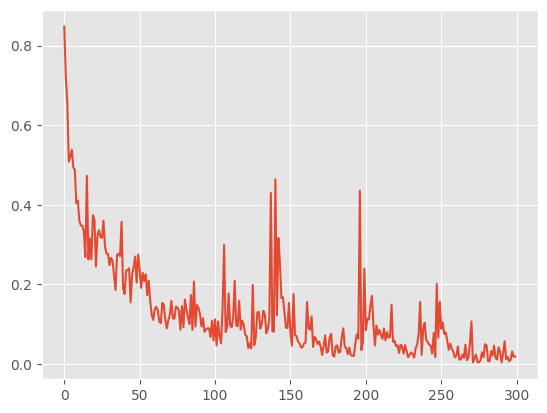

In [13]:
plt.plot(h)

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: divide by zero encountered in matmul
  return x @ self.W + self.b                 # (B, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: overflow encountered in matmul
  return x @ self.W + self.b                 # (B, out)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_40004/2293613667.py:33: RuntimeWarning: invalid value encountered in matmul
  return x @ self.W + self.b                 # (B, out)


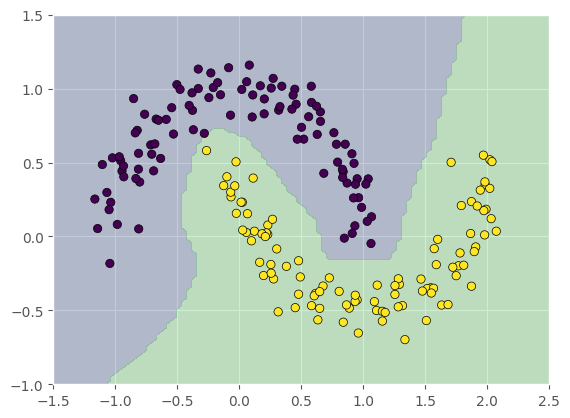

In [14]:
logits = plot_decision_boundary(model)